In [4]:
%reload_ext autoreload
%autoreload 2

import os
import pickle
import numpy as np
import healpy as hp
import json

import sys
sys.path.append("..")

from utils.multi_corner import multi_corner


import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../nptf-test/production/matplotlibrc")

In [8]:
run_name = 'hmc_s1k_fexp-2_ns0_kmaxfix_fexp'
s_hmc = pickle.load(open(f"../outputs/fit/{run_name}/i0_n10000.p", "rb"))
print(s_hmc.keys())

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'Alm_5', 'C', 'S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_bulge_poiss', 'theta_bulge_ps', 'theta_ics', 'theta_pib', 'zs'])


In [9]:
run_name = 'svi_Dbase1023_fexp_Mnp_nstest'
s_svi = pickle.load(open(f"../outputs/fit/{run_name}/i0_n50000_ns10000.p", "rb"))
print(s_hmc.keys())

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'Alm_5', 'C', 'S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_bulge_poiss', 'theta_bulge_ps', 'theta_ics', 'theta_pib', 'zs'])


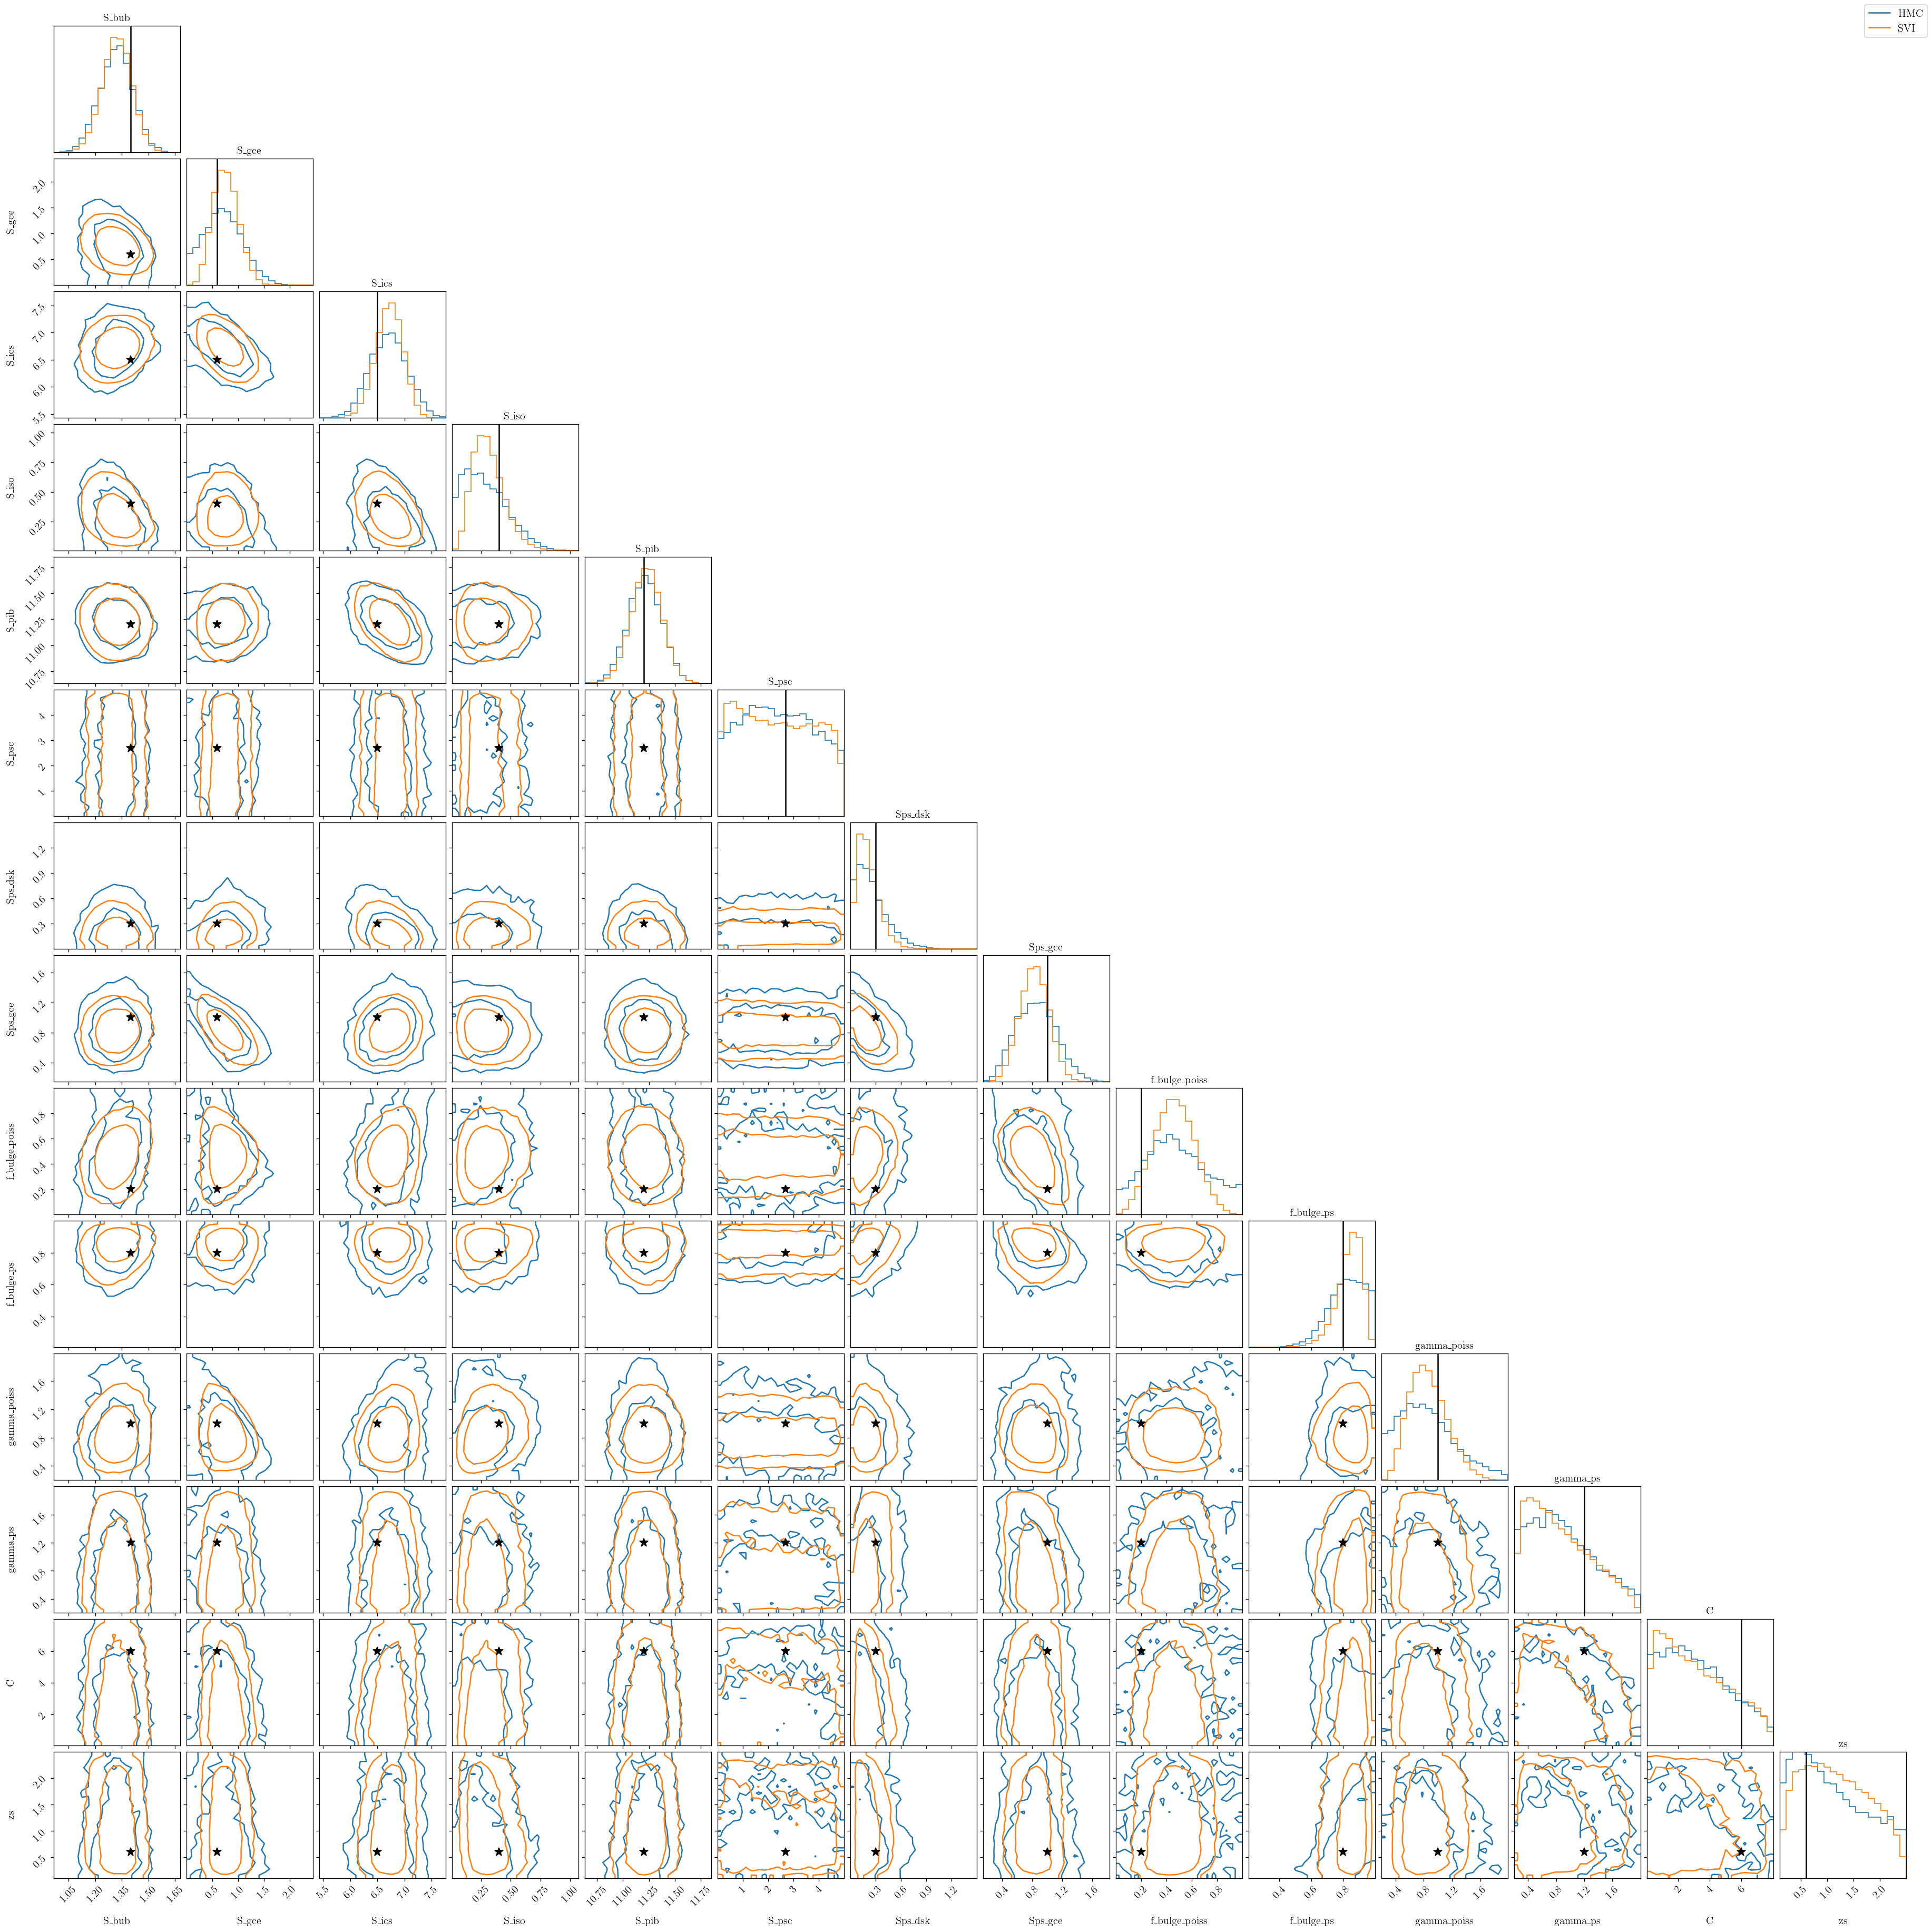

In [10]:
labels = ['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce',
          'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps',
        #   'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce',
          'C', 'zs'
]

samples_dict = {
    'hmc' : {k : np.array(s_hmc[k]) for k in labels},
    'svi' : {k : np.array(s_svi[k]) for k in labels},
}
labels_dict = {
    'hmc' : 'HMC',
    'svi' : 'SVI',
}
colors_dict = {
    'hmc' : 'C0',
    'svi' : 'C1',
}

truth_dict = json.load(open('truth_dict.json', 'r'))
t_in = {k: truth_dict[k] for k in labels}

multi_corner(samples_dict, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)